# Churn Prediction
Shortcut to run all blocks: ESC, CTRL + A, SHIFT + ENTER

## Imports

In [869]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, Normalizer

# For working with imbalanced datasets
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, ADASYN

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

## Dataset Info

In [870]:
CSV_FILE = "Churn_Modelling.csv"
TARGET = "Exited"
UNNECESSARY_FEATURES = ["RowNumber", "CustomerId", "Surname"]
NOMINAL_FEATURES = ["Surname", "Geography", "Gender"]
SELECTED_NOMINAL_FEATURES = list(set(NOMINAL_FEATURES) - set(UNNECESSARY_FEATURES))
RANDOM_STATE = 42
THRESHOLD_FOR_FEATURE_REMOVAL = 0.8
ROWS_TO_DISPLAY = 3

ADD_SYNTHETIC_TRAINING_DATA = False

data_frame = pd.read_csv(CSV_FILE)
data_frame

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


## Dataset Statistics

In [871]:
data_frame.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## No Values Missing

In [872]:
data_frame.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Display Target Class Imbalance

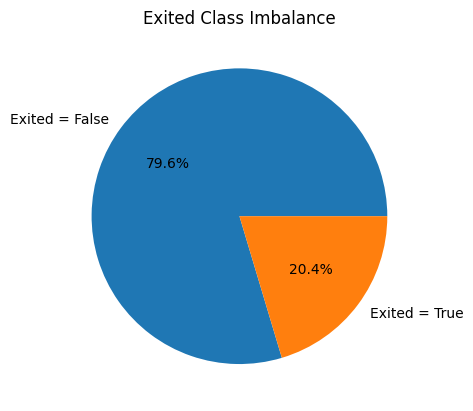

In [873]:
# https://wellsr.com/python/upsampling-and-downsampling-imbalanced-data-in-python/
def frame_target_imbalance(df):
    df.groupby(TARGET).size().plot(kind="pie", y=TARGET, title=f"{TARGET} Class Imbalance", labels=[f"{TARGET} = False", f"{TARGET} = True"], autopct="%1.1f%%")

frame_target_imbalance(data_frame)

## Temporarily Label Encode Selected Nominal Features
This is temporarily done so these features will be shown on the box plot. Using the dataset with Nominal Features being Label Encoded is bad practice because a model might think there is some order to the Nominal Features when there isn't one in reality. We will transform the data frame to use One-hot encoding before training and testing later on. For more information, see https://stackoverflow.com/questions/36631163/what-are-the-pros-and-cons-between-get-dummies-pandas-and-onehotencoder-sciki. Finally, note that One-hot encoding led to an improvement in the Decision Tree's performance below.

In [874]:
label_encoder = LabelEncoder()
for nominal_feature in SELECTED_NOMINAL_FEATURES:
    current_feature_values = data_frame[nominal_feature]
    label_encoder.fit(current_feature_values)
    data_frame[nominal_feature] = label_encoder.transform(current_feature_values)
data_frame.head(ROWS_TO_DISPLAY)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1


## Feature Removal

In [875]:
data_frame = data_frame.drop(columns=UNNECESSARY_FEATURES)
data_frame.head(ROWS_TO_DISPLAY)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1


## Show Unscaled Features

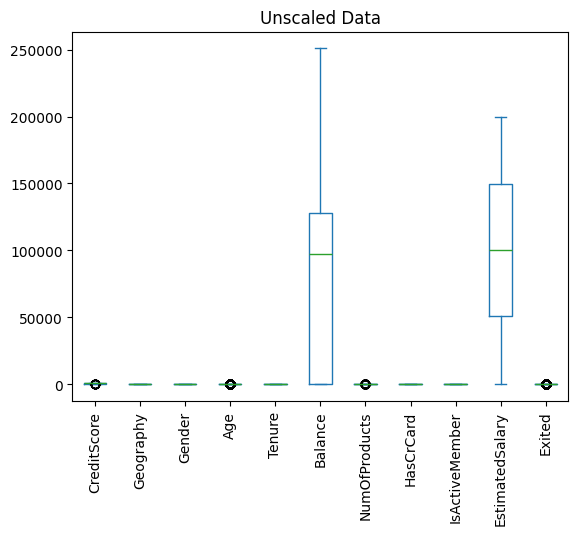

In [876]:
def frame_box_plot(df, title):
    df.plot(kind="box")
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

frame_box_plot(data_frame, "Unscaled Data")

## Show Scaled Features

**NOTE**: Do not use "data_frame_scaled" to produce training and test sets. This is because we do not want to scale the Target "Exited". We want to keep the Target as 0s and 1s. Scaling the Target will lead to problems later on, as it will instead label the values as -1 and 1 respectively. The box plot below is purely for showing the scaled features only.

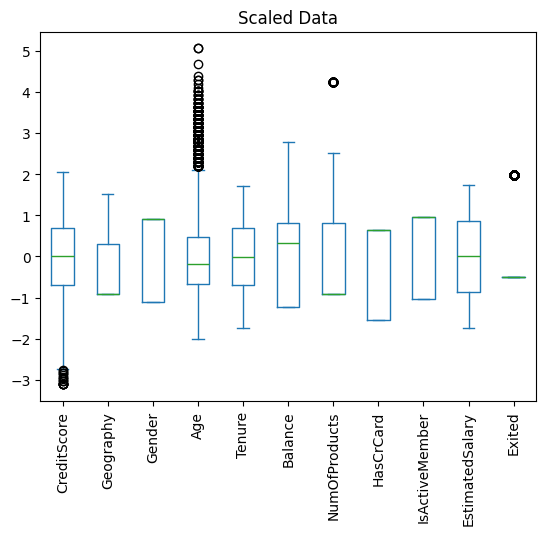

In [877]:
def get_scaled_frame(df):
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df)
    return pd.DataFrame(data=df_scaled, columns=df.columns)

data_frame_scaled = get_scaled_frame(data_frame)
frame_box_plot(data_frame_scaled, "Scaled Data")

## Show Normalized Features

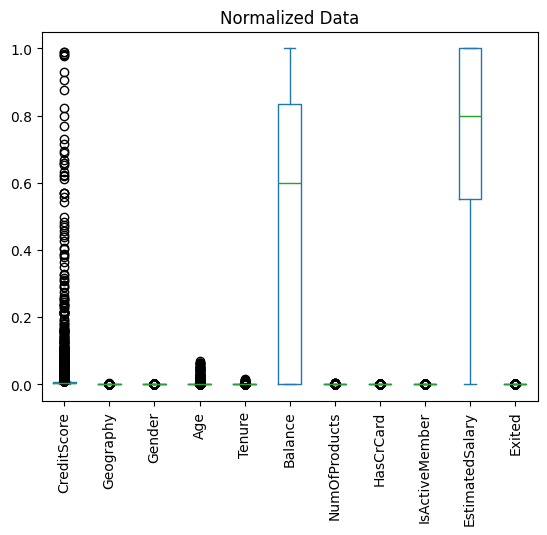

In [878]:
def get_normalized_frame(df):
    normalizer = Normalizer()
    df_normalized = normalizer.fit_transform(df)
    return pd.DataFrame(data=df_normalized, columns=df.columns)

data_frame_normalized = get_normalized_frame(data_frame)
frame_box_plot(data_frame_normalized, "Normalized Data")

## Choosing Outliers for Removal in Training
NumOfProducts seems like it might cause some generalization issues for our models.
Age seems like it captures something important. See how it relates to "Exited" in the Correlation Matrix.
**TODO**: Maybe try removing the lower end of "CreditScore" later on.

In [879]:
# SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = []
# SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = ["Age", "NumOfProducts", "CreditScore"]
# SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = ["Age", "NumOfProducts"]
# SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = ["NumOfProducts", "CreditScore"]
SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING = ["NumOfProducts"]

## One-hot Encoding
**TODO**: Should we set drop_first=True for certain models? See https://datascience.stackexchange.com/questions/47638/in-which-cases-shouldnt-we-drop-the-first-level-of-categorical-variables for more information.

In [880]:
data_frame = pd.get_dummies(data_frame, columns=SELECTED_NOMINAL_FEATURES, drop_first=False)
data_frame.head(ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_0,Gender_1,Geography_0,Geography_1,Geography_2
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,True,False,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,True,False,False


## Show Correlation Among Features

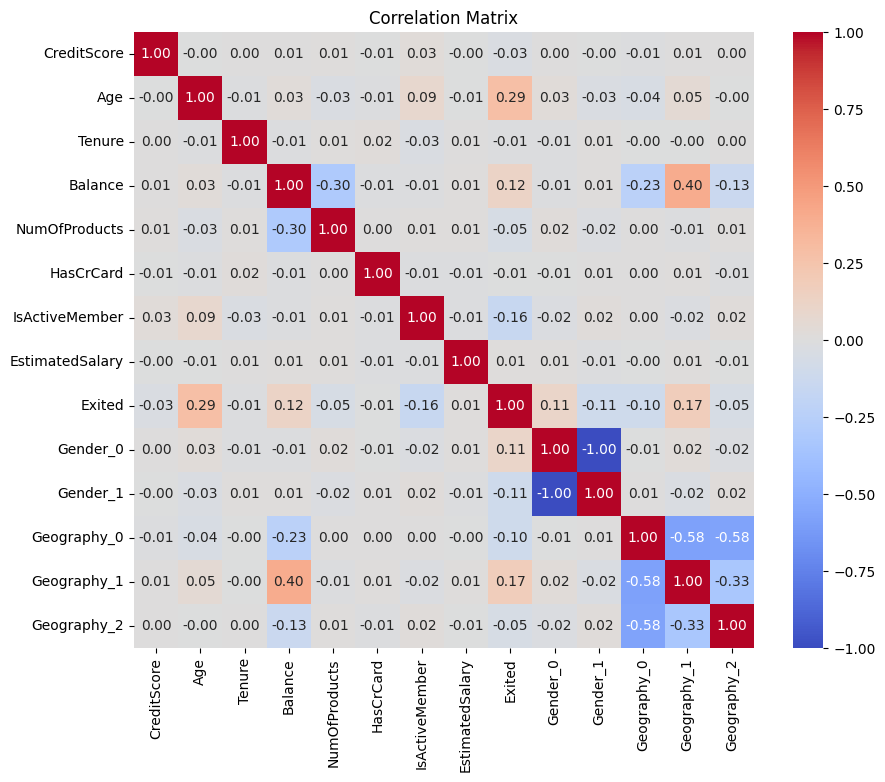

In [881]:
def frame_correlation_matrix(df, threshold=0):
    correlation_matrix = df.corr()
    correlation_matrix[abs(correlation_matrix) < threshold] = 0
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()

frame_correlation_matrix(data_frame)

## Show Features with Highest Correlation

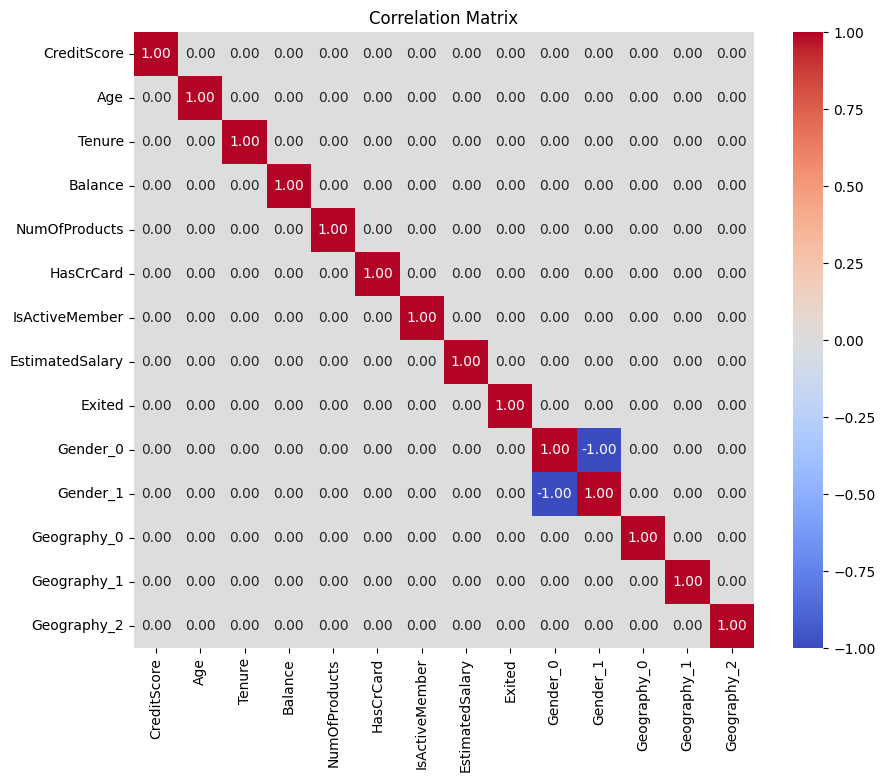

In [882]:
frame_correlation_matrix(data_frame, THRESHOLD_FOR_FEATURE_REMOVAL)

## Drop One Gender Column to Reduce Dimensionality
We do this because it is highly correlated with the other Gender column.

In [883]:
data_frame = data_frame.drop(columns=["Gender_1"])
data_frame.head(ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_0,Geography_0,Geography_1,Geography_2
0,619,42,2,0.00,1,1,1,101348.88,1,True,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,True,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,True,True,False,False


## Define Unscaled Features and Target

In [884]:
def get_x_y(df, scale=False, normalize=False):
    x = df.drop(columns=[TARGET])
    if scale:
        x = get_scaled_frame(x)
    elif normalize:
        x = get_normalized_frame(x)
    y = df[TARGET]
    return x, y

x, y = get_x_y(data_frame)
x.head(ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_0,Geography_0,Geography_1,Geography_2
0,619,42,2,0.00,1,1,1,101348.88,True,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,True,False,False,True
2,502,42,8,159660.80,3,1,0,113931.57,True,True,False,False


## Define Scaled Features
**TODO**: Add normalization. Look into which models benefit from unscaled, scaled and normalized data.

In [885]:
x_scaled, _ = get_x_y(data_frame, scale=True)
x_normalized, _ = get_x_y(data_frame, scale=False, normalize=True)
x_scaled.head(ROWS_TO_DISPLAY)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_0,Geography_0,Geography_1,Geography_2
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,1.095988,0.997204,-0.578736,-0.573809
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,1.095988,-1.002804,-0.578736,1.742740
2,-1.536794,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,1.095988,0.997204,-0.578736,-0.573809


## Skipping Principal Component Analysis
Based on a little bit of research, it seems safer to omit PCA from our project.

## Define Functions for Testing Models

In [886]:
def call_train_test_split(x, y):
    return train_test_split(x, y, test_size=0.2, train_size=0.8, random_state=RANDOM_STATE, stratify=y)

def custom_train_test_split(x, y, selected_outliers, add_synthetic_training_data):
    x_train, x_test, y_train, y_test = call_train_test_split(x, y)
    
    # https://stackoverflow.com/questions/74683825/how-do-i-remove-outliers-from-a-column-in-a-dataframe
    if selected_outliers:
        df_train = x.copy()
        # Reconstruct data frame using x and y. Essentially, concatenate x with y to produce the original dataframe.
        # This is done because we need to keep x and y consistent with each other.
        # When we remove an outlier from x, we also need to remove the corresponding row in y.
        df_train[TARGET] = y
        for outlier in selected_outliers:
            quantile1 = df_train[outlier].quantile(0.25)
            quantile3 = df_train[outlier].quantile(0.75)
            interquartile_range = quantile3 - quantile1

            low = quantile1 - 1.5 * interquartile_range
            high = quantile3 + 1.5 * interquartile_range

            df_train = df_train[df_train[outlier] > low]
            df_train = df_train[df_train[outlier] < high]

        x_removed_outliers, y_removed_outliers = get_x_y(df_train)
        x_train, _, y_train, _ = call_train_test_split(x_removed_outliers, y_removed_outliers)

    if add_synthetic_training_data:
        adasyn = ADASYN(random_state=RANDOM_STATE)
        smote = SMOTE(random_state=RANDOM_STATE)
        smote_enn = SMOTEENN(random_state=RANDOM_STATE)
        
        x_train, y_train = adasyn.fit_resample(x_train, y_train)
        # x_train, y_train = smote.fit_resample(x_train, y_train)
        # x_train, y_train = smote_enn.fit_resample(x_train, y_train)
    
    return x_train, x_test, y_train, y_test

def test_model(model, x, y, selected_outliers=[], add_synthetic_training_data=False):
    x_train, x_test, y_train, y_test = custom_train_test_split(x, y, selected_outliers, add_synthetic_training_data)
    model.fit(x_train, y_train)
    y_test_predicted = model.predict(x_test)

    print(model)
    print(classification_report(y_test, y_test_predicted))
    # return model

## Imbalanced Dataset Handling

In [887]:
def generate_binary_class_weights(rate_of_change=0.05, majority_class=0, minority_class=1):
    class_weights = []
    assert rate_of_change > 0
    majority_value = 1 - rate_of_change
    minority_value = 1 - majority_value
    while majority_value > 0 and minority_value < 1:
        class_weight = {}
        class_weight[majority_class] = round(majority_value, 2)
        class_weight[minority_class] = round(1 - majority_value, 2)

        majority_value -= rate_of_change

        class_weights.append(class_weight)

    return class_weights

## Test Decision Tree (Untuned)

In [888]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
test_model(tree, x, y)

DecisionTreeClassifier(random_state=42)
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1593
           1       0.47      0.51      0.49       407

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.79      0.78      0.79      2000



## Test Decision Tree (Tuned)

In [889]:
for class_weight in generate_binary_class_weights():
    tree = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=class_weight)
    test_model(tree, x_normalized, y, selected_outliers=SELECTED_OUTLIERS_FOR_REMOVAL_IN_TRAINING, add_synthetic_training_data=ADD_SYNTHETIC_TRAINING_DATA)

DecisionTreeClassifier(class_weight={0: 0.95, 1: 0.05}, random_state=42)
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1593
           1       0.73      0.89      0.80       407

    accuracy                           0.91      2000
   macro avg       0.85      0.90      0.87      2000
weighted avg       0.92      0.91      0.91      2000

DecisionTreeClassifier(class_weight={0: 0.9, 1: 0.1}, random_state=42)
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      1593
           1       0.74      0.87      0.80       407

    accuracy                           0.91      2000
   macro avg       0.85      0.90      0.87      2000
weighted avg       0.92      0.91      0.92      2000

DecisionTreeClassifier(class_weight={0: 0.85, 1: 0.15}, random_state=42)
              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1593
           1       0